<a href="https://colab.research.google.com/github/alitourani/vision-paper-hub/blob/main/categories/semseg/mask2former/mask2former2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **👁️‍🗨️ Vision Paper Hub** / **Semantic Segmentation** / **Mask2Former**

This colaboratory is made to assess the quality of Mask2Former library.

- 🚀 [Benchmark](https://github.com/alitourani/vision-paper-hub/tree/main/categories/semseg/mask2former)
- 🔗 [GitHub Repo](https://github.com/facebookresearch/mask2former)
- 📃 [Paper](https://doi.org/10.48550/arXiv.2112.01527)

## **I. Install the Repository**

We start with HF Transformers, which can be installed via `pip` as below:

In [1]:
!pip install transformers accelerate huggingface_hub -qq

In [3]:
import os
import sys

google_colab = "google.colab" in sys.modules and not os.environ.get("VERTEX_PRODUCT")

# Load the HF secret token
if google_colab:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
else:
    # Store Hugging Face data under `/content` if running in Colab Enterprise
    if os.environ.get("VERTEX_PRODUCT") == "COLAB_ENTERPRISE":
        os.environ["HF_HOME"] = "/content/hf"
    # Authenticate with Hugging Face
    ! uv pip install huggingface_hub
    from huggingface_hub import get_token
    if get_token() is None:
        from huggingface_hub import notebook_login
        notebook_login()

## **II. Upload an Image**

Saving road.png to road.png
- File "road.png" uploaded with length 451113 bytes.


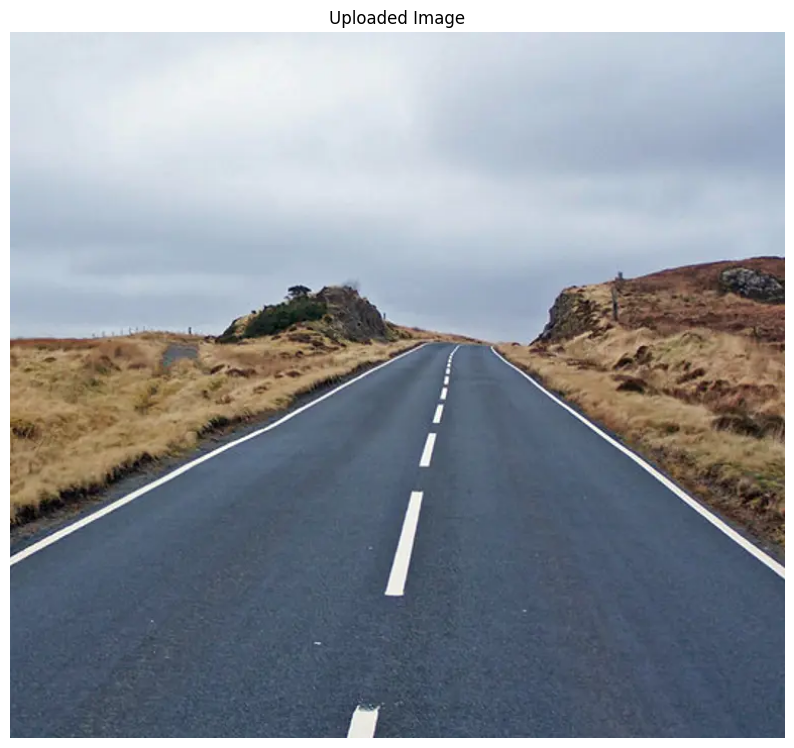

In [9]:
import os
import tempfile
import cv2 as cv
import numpy as np
import PIL.Image as Image
from google.colab import files
import matplotlib.pyplot as plt

# Variable for uploading files
image_path = ""
image_cv = None
image_pil = None
uploaded = files.upload()

for fn in uploaded.keys():
  print('- File "{name}" uploaded with length {length} bytes.'.format(
      name=fn, length=len(uploaded[fn])))

  # Save the uploaded file to a temporary location
  suffix = os.path.splitext(fn)[1] # Get extension
  with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp_file:
    tmp_file.write(uploaded[fn])
    image_path = tmp_file.name

  try:
    # Load the image using OpenCV
    image_cv = cv.imread(image_path)
    # Load as PIL image
    image_pil = Image.fromarray(cv.cvtColor(image_cv, cv.COLOR_BGR2RGB))
  except Exception as X:
    print(f"[Error]: Could not load image '{fn}' with OpenCV!")

  # Display the image
  if image_pil is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(image_pil)
    plt.title(f"Uploaded Image")
    plt.axis('off')
    plt.show()

## **III. Semantic Segmentation using Mask2Former**

- First, you need to load a model checkpoint for semantic segmentation:

In [5]:
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

# Load Mask2Former trained on ADE20k
image_processor = AutoImageProcessor.from_pretrained("facebook/mask2former-swin-small-ade-semantic")
model = Mask2FormerForUniversalSegmentation.from_pretrained("facebook/mask2former-swin-small-ade-semantic")

preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

The image processor of type `Mask2FormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/276M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Segmentation map saved as 'semseg_20260402_084600.png'


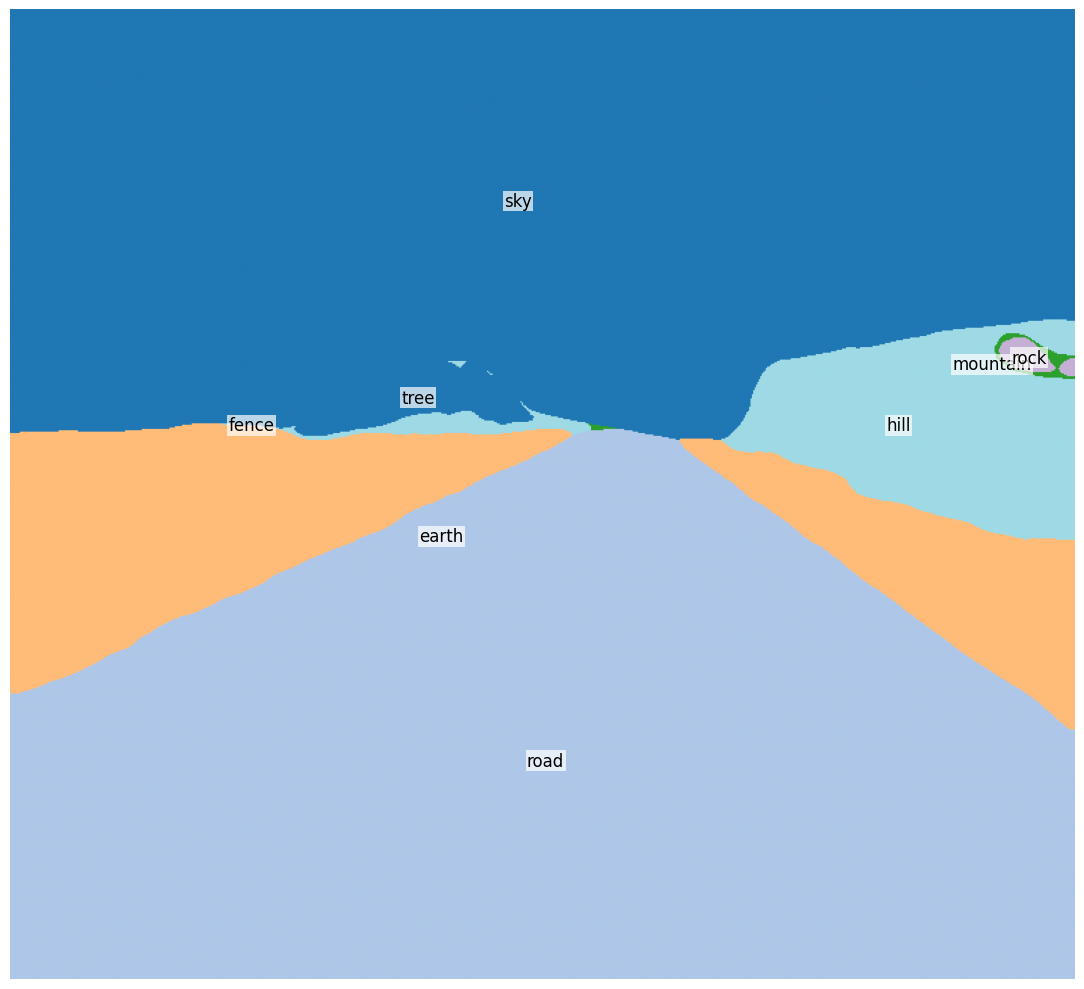

In [10]:
import torch
import datetime
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Convert into a PyTorch tensor
inputs = image_processor(image_pil, return_tensors="pt")

# Process the tensor
with torch.no_grad():
  outputs = model(**inputs)

class_queries_logits = outputs.class_queries_logits
masks_queries_logits = outputs.masks_queries_logits

# Convert the raw model outputs into a semantic segmentation map
semseg_map = image_processor.post_process_semantic_segmentation(
    outputs, target_sizes=[(image_pil.height, image_pil.width)]
)[0]

# Translate the numerical class IDs into labels
id2label = model.config.id2label

# Prepare the map for visualization
semseg_map_np = semseg_map.cpu().numpy()

# Get unique class IDs
unique_ids = np.unique(semseg_map_np)

# Determine the maximum class ID to ensure the colormap has enough distinct colors
max_id = max(unique_ids) if unique_ids.size > 0 else 0

# Create a discrete colormap with enough colors for all class IDs found.
num_colors = max(max_id + 1, 1)
cmap = plt.get_cmap('tab20', num_colors) # Using tab20 for distinct colors

# Visualization
plt.figure(figsize=(12, 10))
plt.imshow(semseg_map_np, cmap=cmap)
plt.axis('off')

# Add text labels for each segment
for class_id in sorted(unique_ids):
  if class_id in id2label:
    label_name = id2label[class_id]
    mask = (semseg_map_np == class_id)
    y_coords, x_coords = np.where(mask)

    if y_coords.size > 0:
      center_x = int(np.mean(x_coords))
      center_y = int(np.mean(y_coords))

      plt.text(
        center_x, center_y, label_name,
        color='black', fontsize=12, ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
      )

# Display the image
plt.tight_layout()

# Generate timestamp for filename
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"semseg_{timestamp}.png"

# Save the plot
plt.savefig(filename, bbox_inches='tight')
print(f"Segmentation map saved as '{filename}'")

plt.show()